# Strain mapping of a battery cathode particle (Li$_x$FePO$_4$)

This notebook measures **strain maps** from an experimental 4D-STEM dataset: a thick (several hundred nanometer) Li$_x$FePO$_4$ (LFP) battery cathode nanoplatelet, imaged along the [010] zone axis, which has been partially electrochemically cycled.

**The science.** LFP is a workhorse Li-ion cathode material. During charging, lithium leaves the crystal; during discharge it returns. The lattice responds: as Li is removed, the long $a$ axis *contracts* (by about 5%) and the short $c$ axis *expands* (by about 2%). A partially cycled particle therefore contains coexisting lithiated and delithiated domains — and the strain map reveals their arrangement directly.

**The method.** Strain mapping from nanobeam diffraction rests on a simple idea: the spacing of the Bragg disks is inversely proportional to the local lattice spacing. Measure the disk positions precisely at every probe position, fit a lattice to them, and compare the local lattice vectors to a reference — the fractional change is the strain. The workflow is: detect disks → calibrate carefully (center, ellipticity, rotation) → fit lattice vectors everywhere → convert to strain. Most of the effort goes into the calibration, because strain is a *percent-level* measurement of disk positions.

*Prerequisite: the basics notebook (data loading, virtual imaging, disk detection).*

---

## Tutorial data

The notebook downloads its data automatically. Direct links:

* [Partially cycled Li$_x$FePO$_4$ 4D-STEM data](https://drive.google.com/file/d/1uYB23czoa7U05CtHVx9zfiVQFjiPfJUy/view?usp=drive_link) (265 MB)

### Acknowledgements

This tutorial was created by the py4DSTEM instructor team:
Ben Savitzky, Steve Zeltmann, Stephanie Ribet (sribet@lbl.gov), Alex Rakowski, and Colin Ophus (cophus@stanford.edu).

Experimental data was collected by Lauren Hughes. For more on this system, see
[Hughes et al., Materials Today 52 (2022)](https://doi.org/10.1016/j.mattod.2021.10.031) and [Deng et al., Nature Materials 21 (2022)](https://doi.org/10.1038/s41563-021-01191-0).

### Running this notebook

This notebook is designed for **Google Colab** — every cell also runs in a local Jupyter session with py4DSTEM installed. Run the cells top to bottom; each section explains what it does and why before the code.

# Set up the environment

In [3]:
# Install py4DSTEM and pymatgen (crystal structures). On Google Colab this
# takes a few minutes -- start it now and read ahead while you wait!
#pip install -q git+https://github.com/cophus/py4DSTEM.git@dev pymatgen anywidget
# (once the numpy-2 fix is merged upstream, this becomes:
%pip install -q git+https://github.com/py4dstem/py4DSTEM.git@dev pymatgen

  Preparing metadata (setup.py) ... done


If Colab shows a message asking you to **restart the session** after the installation finishes, do so (*Runtime → Restart session*) and then continue from the imports cell below — the installed packages are kept.

In [4]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt

print('py4DSTEM version:', py4DSTEM.__version__)

py4DSTEM version: 0.14.19


# Download and load the data

In [5]:
import os

dirpath = '/content/'
filepath_data = dirpath + 'LFP_particle_4DSTEM.h5'

if not os.path.exists(filepath_data):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=1uYB23czoa7U05CtHVx9zfiVQFjiPfJUy',
        destination = dirpath,
        filename = 'LFP_particle_4DSTEM.h5',
        overwrite = True,
    )

Downloading...
From (original): https://drive.google.com/uc?id=1uYB23czoa7U05CtHVx9zfiVQFjiPfJUy
From (redirected): https://drive.google.com/uc?id=1uYB23czoa7U05CtHVx9zfiVQFjiPfJUy&confirm=t&uuid=136c6090-9268-4898-a01b-d89868a1e599
To: /content/LFP_particle_4DSTEM.h5
100%|██████████| 265M/265M [00:02<00:00, 98.9MB/s]


In [6]:
datacube = py4DSTEM.read(filepath = filepath_data)

datacube

DataCube( A 4-dimensional array of shape (90, 45, 128, 128) called 'datacube',
          with dimensions:

              Rx = [0.0,49.5,99.0,...] nm
              Ry = [0.0,49.5,99.0,...] nm
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)

The scan is 90 × 45 probe positions (with a large ~50 nm step — this particle is several microns across) and each diffraction pattern is 128 × 128 pixels.

# Examine the data

As always, we start with the mean and max diffraction patterns:

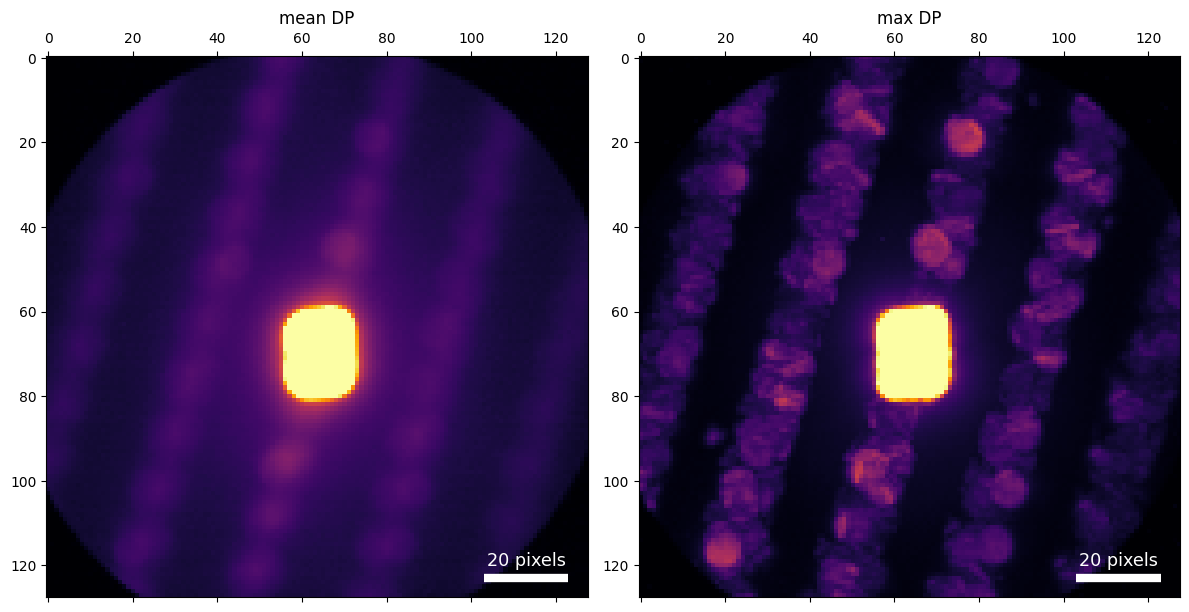

In [7]:
dp_mean = datacube.get_dp_mean()
dp_max = datacube.get_dp_max()

py4DSTEM.show(
    [dp_mean, dp_max],
    cmap = 'inferno',
    title = ['mean DP', 'max DP'],
    power = 0.5,
)

**Look closely at the central spot: it is shaped like a rounded rectangle, not a circle.** That is not the beam's real shape — it is the circular direct beam *smeared out* by **descan**: as the probe scans across the sample, the whole diffraction pattern drifts on the detector by several pixels. Averaged over the scan, the wandering circular beam paints a rectangle.

Descan is very common in real 4D-STEM experiments (it comes from imperfect scan/de-scan alignment of the microscope). For percent-level strain measurements a few pixels of drift is enormous, so we will measure and correct it below. Keep it in mind as you browse:

## Browse the data interactively

Before running any analysis, it is *always* worth exploring a 4D-STEM dataset by hand. The cell below downloads a small interactive browser widget: **click or drag on the left (real-space) panel to move the electron probe**, and the right panel shows the diffraction pattern recorded at that position.

Each panel has its own contrast controls: the small histogram below the image shows the distribution of displayed intensities — **drag the two blue markers** to set the display window (it defaults to the 2%–98% intensity quantiles) — and the **power slider** compresses the dynamic range (diffraction spans many orders of magnitude, so powers well below 1 are usually best on the right panel).

Browsing builds intuition fast: where the sample is, how strongly it diffracts, whether the patterns shift on the detector, and what artifacts to look out for.

In [8]:
# Download the interactive 4D-STEM data browser widget.
import os, sys

if not os.path.exists('/content/browse_4dstem.py'):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c',
        destination = '/content/',
        filename = 'browse_4dstem.py',
    )
sys.path.append('/content')

# on Colab, third-party widgets need the custom widget manager enabled
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass   # not on Colab

from browse_4dstem import browse_4dstem

Downloading...
From (original): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c
From (redirected): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c&confirm=t&uuid=0a7fa654-220a-4e64-9f0a-2502177c2b68
To: /content/browse_4dstem.py
100%|██████████| 17.1k/17.1k [00:00<00:00, 29.3MB/s]


In [9]:
browse_4dstem(datacube.data)

Notice as you move around: on the thick particle the direct beam is strongly attenuated and many Bragg disks appear; off the particle the beam is intense and nearly unscattered. Watch the pattern *position* shift slightly as you scan — that is the descan.

# Virtual imaging

Bright-field and annular dark-field images give us a map of the particle:

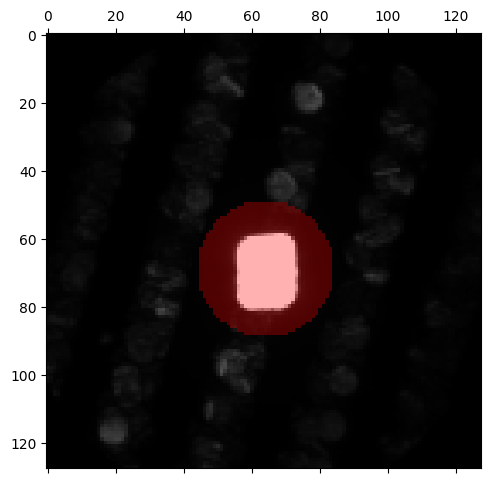

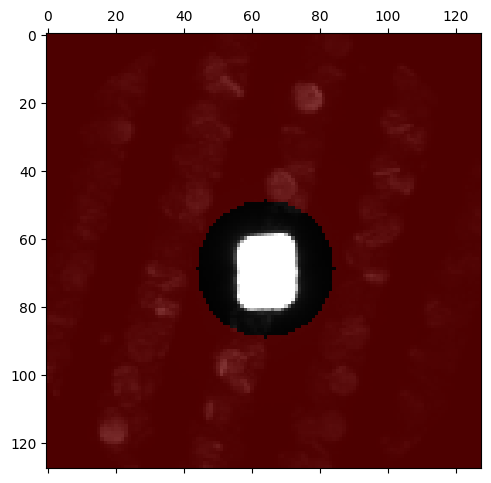

In [10]:
# place the virtual detectors
center = (69, 64)
radius_bf = 20

geometry_bf = (center, radius_bf)
geometry_adf = (center, (radius_bf, 10e3))

datacube.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
datacube.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

100%|██████████| 4050/4050 [00:00<00:00, 30637.17it/s]


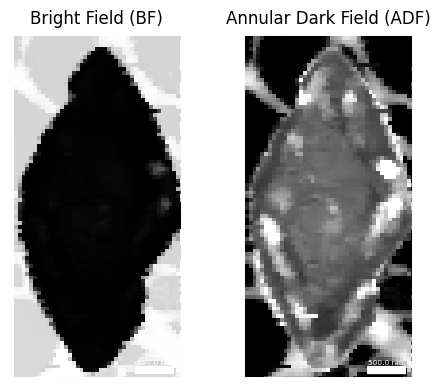

In [11]:
im_bf = datacube.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field',
)
im_adf = datacube.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field',
)

py4DSTEM.show(
    [im_bf, im_adf],
    cmap = 'gray',
    title = ['Bright Field (BF)', 'Annular Dark Field (ADF)'],
    axsize = (2.5, 4),
    bordercolor = 'w',
)

The platelet is the large dark (BF) / bright (ADF) diamond shape; around it you can see holes and the lacy carbon support film.

# Construct the probe template

Disk detection needs a template of the probe. This scan conveniently includes vacuum in its upper-left corner — first check what a single vacuum pattern looks like, then average a small region of them into a clean probe image:

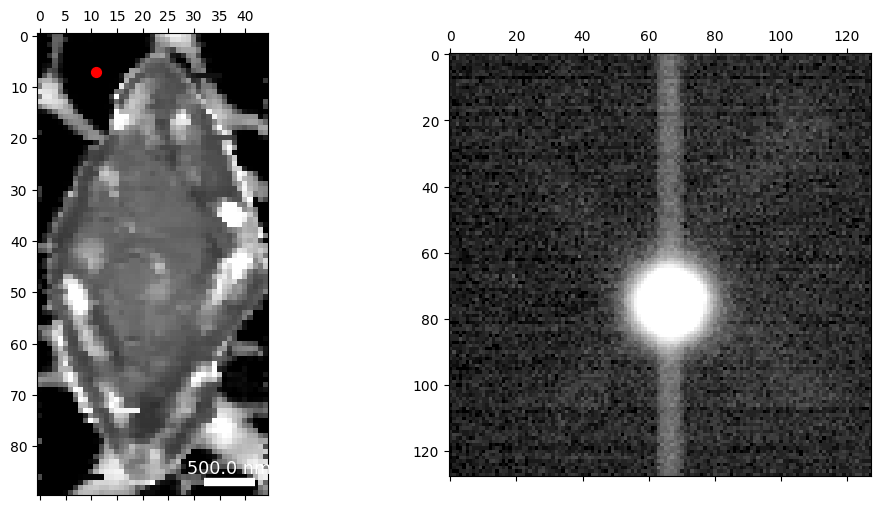

In [12]:
rx, ry = 7, 11

py4DSTEM.visualize.show_selected_dp(
    datacube,
    im_adf,
    rx,
    ry,
)

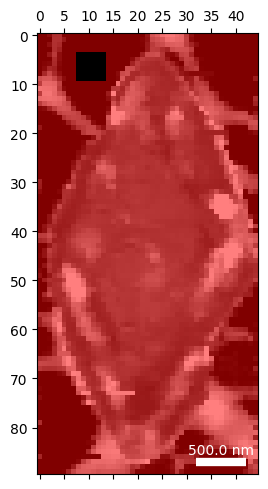

In [13]:
# select a vacuum region of the scan
xlims = 4, 10
ylims = 8, 14

ROI = np.zeros(datacube.rshape, dtype=bool)
ROI[xlims[0]:xlims[1], ylims[0]:ylims[1]] = True

py4DSTEM.show(
    im_adf,
    mask = ROI,
    mask_color = 'r',
    mask_alpha = 0.5,
)

100%|██████████| 35/35 [00:00<00:00, 357.45it/s]


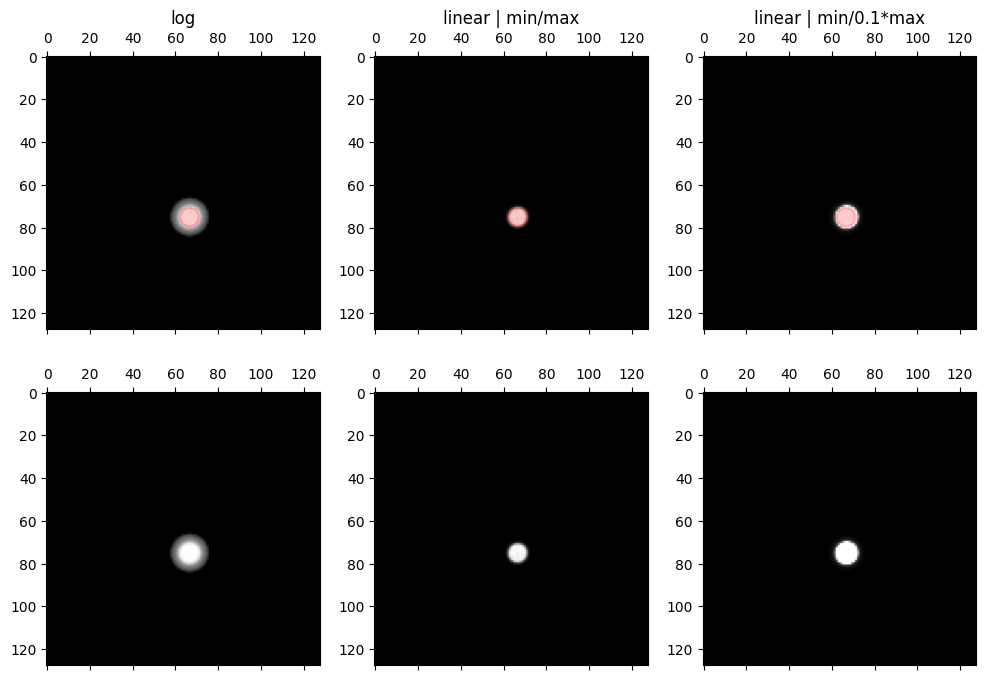

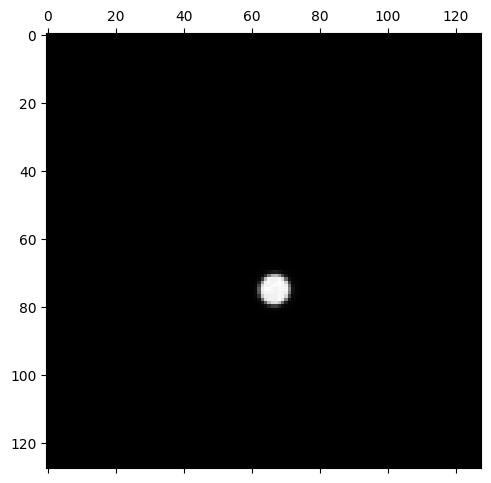

In [14]:
probe = datacube.get_vacuum_probe(ROI = ROI)

py4DSTEM.show(probe.probe, vmax = 1)

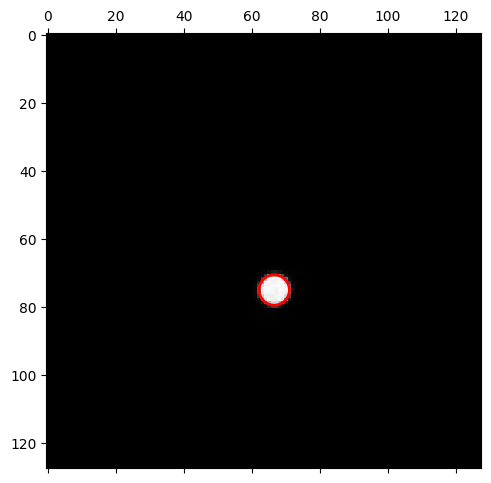

In [15]:
# measure the probe's radius and center
probe_semiangle, probe_qx0, probe_qy0 = py4DSTEM.process.calibration.get_probe_size(probe.probe)

py4DSTEM.show(
    probe.probe,
    circle = {
        'center': (probe_qx0, probe_qy0),
        'R': probe_semiangle,
    },
    vmax = 1,
)

Now build the correlation kernel — the probe surrounded by a negative "trench" that sharpens the correlation peaks (see the basics notebook for why):

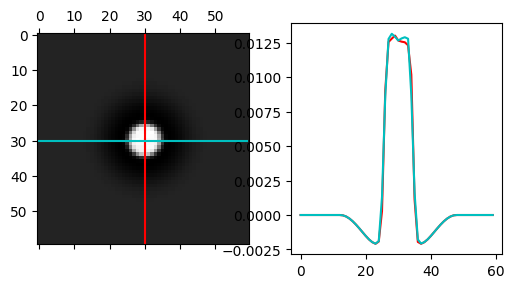

In [16]:
probe.get_kernel(
    mode = 'sigmoid',
    origin = (probe_qx0, probe_qy0),
    radii = (probe_semiangle * 1, probe_semiangle * 4),
)

py4DSTEM.visualize.show_kernel(
    probe.kernel,
    R = 30, L = 30, W = 1,
    figsize = (6, 3),
)

# Find the Bragg disks

## Tune the detection on test patterns

We pick six probe positions spread over the particle and check the detection visually before running everything. Because strain needs very precise disk positions, we use `subpixel='multicorr'` (Fourier-upsampled refinement, precise to a few hundredths of a pixel) rather than the faster `'poly'`.

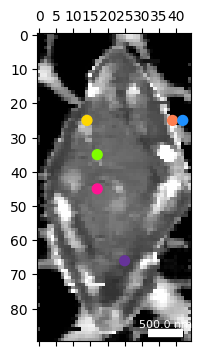

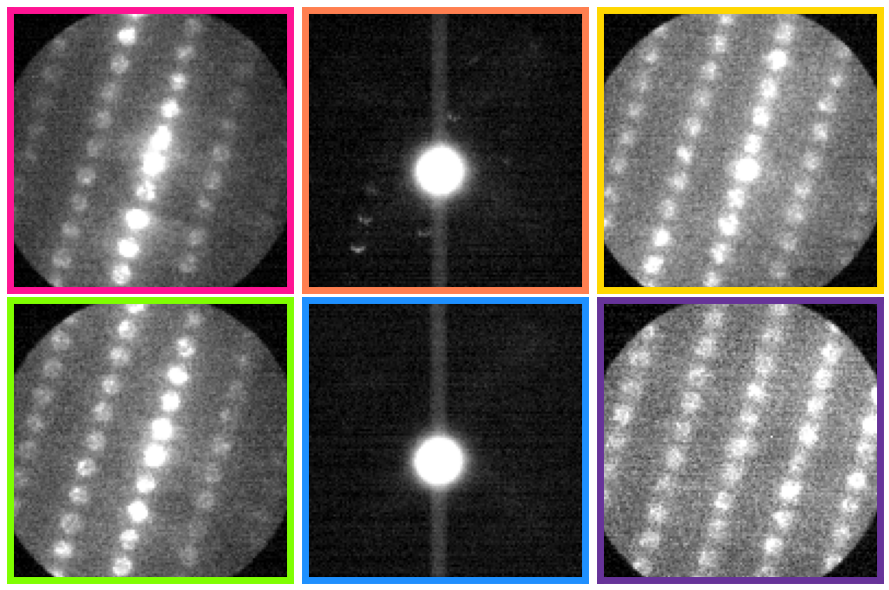

In [17]:
rxs = 45, 25, 25, 35, 25, 66
rys = 17, 39, 14, 17, 42, 25

colors = ['deeppink', 'coral', 'gold', 'chartreuse', 'dodgerblue', 'rebeccapurple']

py4DSTEM.visualize.show_points(
    im_adf,
    x = rxs, y = rys,
    pointcolor = colors,
    figsize = (4, 4),
)

py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i: datacube.data[rxs[i], rys[i], :, :],
    H = 2, W = 3,
    axsize = (3, 3),
    power = 0.5,
    get_bordercolor = lambda i: colors[i],
)

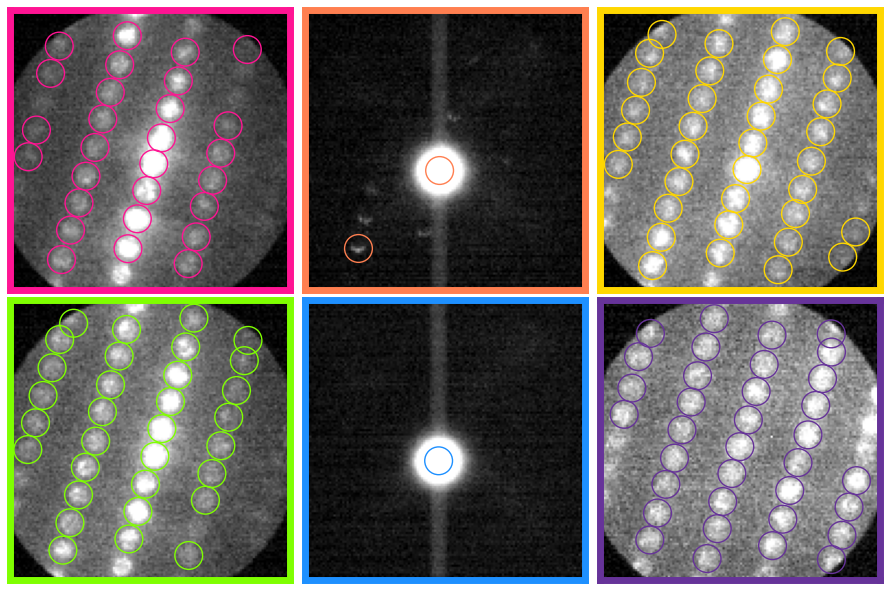

In [18]:
detect_params = {
    'corrPower': 1.0,
    'sigma': 0,
    'edgeBoundary': 8,
    'minRelativeIntensity': 0,
    'minAbsoluteIntensity': 8,
    'minPeakSpacing': 4,
    'subpixel': 'multicorr',   # high-precision subpixel fitting -- required for strain!
    'upsample_factor': 8,
    'maxNumPeaks': 1000,
}

disks_selected = datacube.find_Bragg_disks(
    data = (rxs, rys),
    template = probe.kernel,
    **detect_params,
)

py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i: datacube.data[rxs[i], rys[i], :, :],
    H = 2, W = 3,
    axsize = (3, 3),
    power = 0.5,
    get_bordercolor = lambda i: colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 400,
)

Check that every visible disk is marked in each test pattern, then run the full detection over all 4,050 patterns (this takes a few minutes):

In [19]:
braggpeaks = datacube.find_Bragg_disks(
    template = probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 4.05k/4.05k [01:26<00:00, 46.9DP/s]


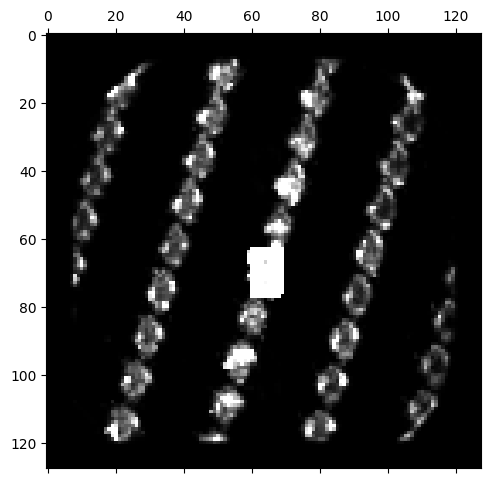

In [20]:
# the Bragg vector map: a 2D histogram of every detected disk position
py4DSTEM.show(braggpeaks.histogram())

# Calibration

Strain is a *relative, percent-level* measurement of disk positions, so we must remove every instrumental distortion first. Three calibrations, in order:

1. **Centering (descan):** find the pattern center at every probe position and fit a smooth model to it.
2. **Ellipticity:** the projector lenses stretch the pattern slightly (typically ~1%); measure and correct it.
3. **Rotation:** the detector is rotated relative to the scan axes; we need the angle to express strain in sample coordinates.

## Center the coordinate system

The raw Bragg vector map shows each diffraction peak smeared by the descan:

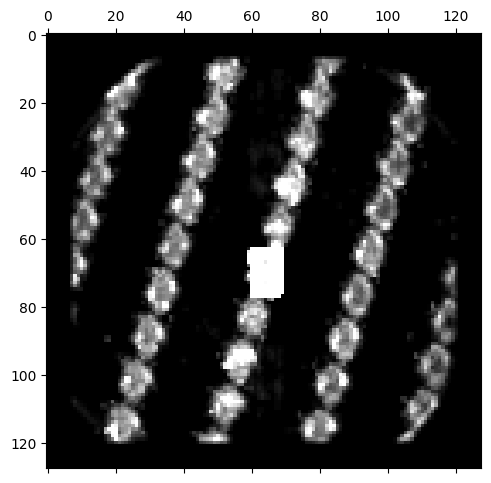

In [21]:
bvm_raw = braggpeaks.histogram(mode = 'raw')

bvm_vis_params = {
    'scaling': 'power',
    'power': 0.5,
}

py4DSTEM.show(bvm_raw, **bvm_vis_params)

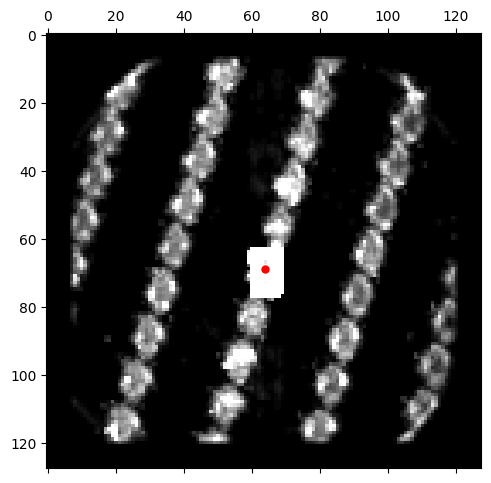

In [22]:
# an initial guess for the pattern center
center_guess = 69, 64

py4DSTEM.show(
    bvm_raw,
    points = {'x': center_guess[0], 'y': center_guess[1]},
    **bvm_vis_params,
)

`measure_origin` finds the direct beam in every pattern, and `fit_origin` fits a smooth plane to those positions — descan is almost perfectly linear in probe position, so the plane captures the true beam drift while averaging away measurement noise. The residual maps (right panels below) should look like structureless noise; any leftover pattern would mean the fit missed something real.

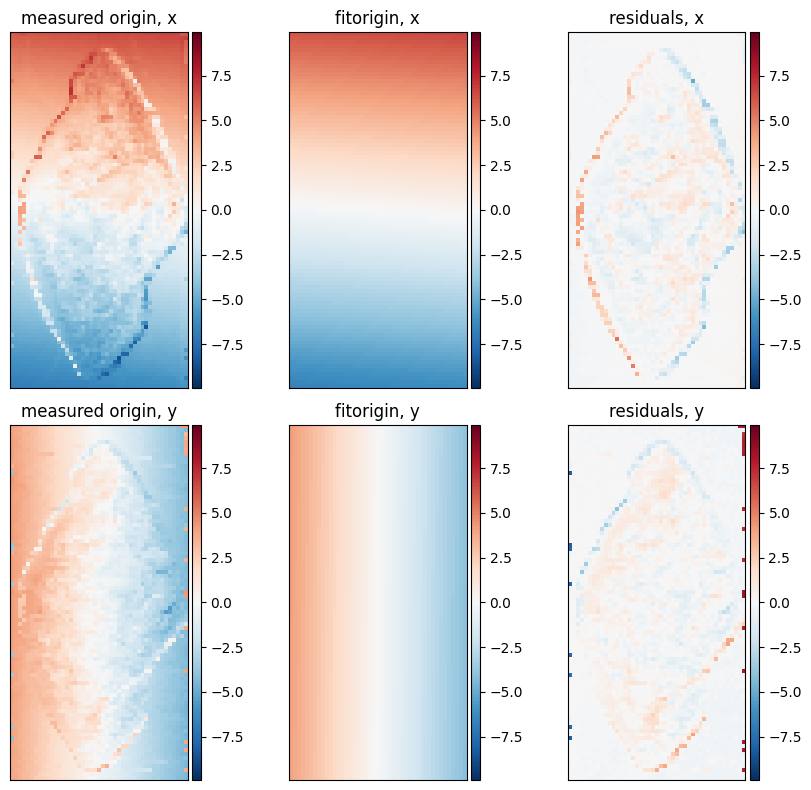

In [23]:
origin_meas = braggpeaks.measure_origin(center_guess = center_guess)

qx0_fit, qy0_fit, qx0_residuals, qy0_residuals = braggpeaks.fit_origin(
    ticks = False,
    axsize = (3, 4),
)

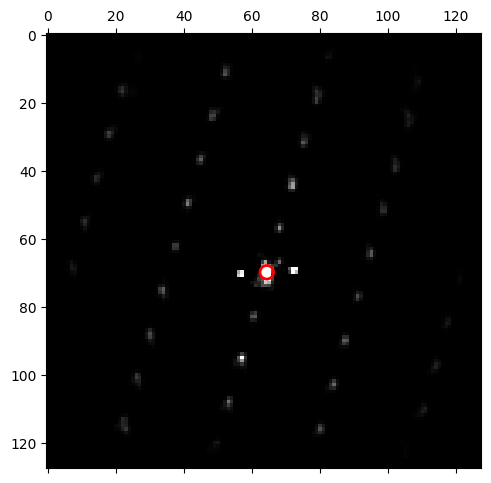

In [24]:
# the Bragg vector map after centering -- much sharper!
bvm_centered = braggpeaks.histogram()

py4DSTEM.show(
    bvm_centered,
    circle = {
        'center': bvm_centered.origin,
        'R': 2,
    },
    vmin = 0,
    vmax = 0.999,
)

## Ellipticity

To measure the elliptical distortion we need a ring in the diffraction pattern whose true shape we know is circular. Amorphous materials scatter into circular halos — and this sample sits on a lacy *carbon* support. So: select a scan region over thick carbon, average the (centered) patterns there, and fit an ellipse to the amorphous halo.

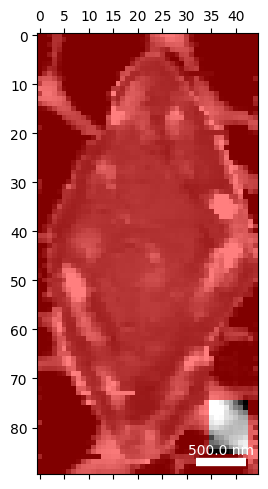

In [25]:
# select a region of thicker lacy carbon
xlims = 75, 86
ylims = 35, 43

ROI_amorph = np.zeros(datacube.rshape, dtype=bool)
ROI_amorph[xlims[0]:xlims[1], ylims[0]:ylims[1]] = True

py4DSTEM.show(
    im_adf,
    mask = ROI_amorph,
    mask_color = 'r',
    mask_alpha = 0.5,
)

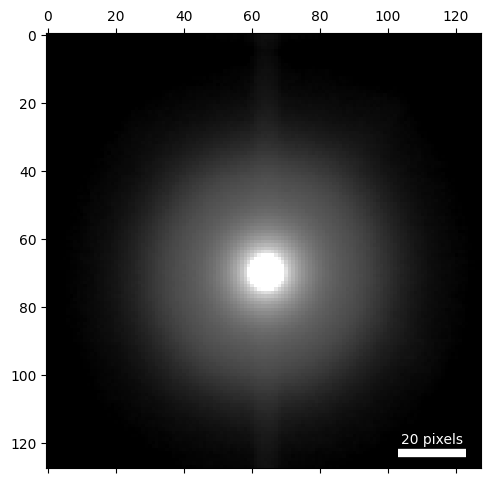

In [26]:
im_SAED_amorph = datacube.get_virtual_diffraction(
    'mean',
    mask = ROI_amorph,
    shift_center = True,   # use our origin fit to center each pattern before averaging
)

py4DSTEM.show(
    im_SAED_amorph,
    intensity_range = 'absolute',
    vmin = 4e1,
    vmax = 8e3,
    scaling = 'log',
)

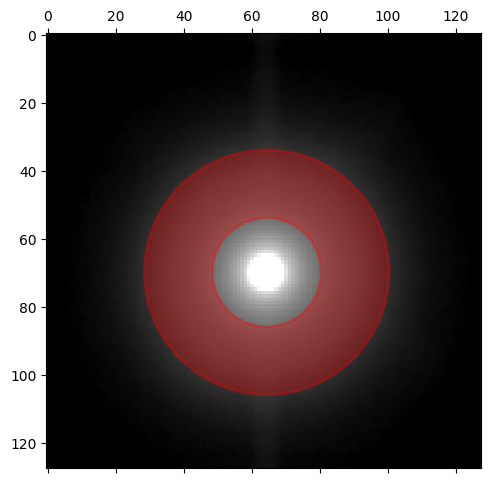

In [27]:
# choose the radial fitting range covering the amorphous halo
q_range = (16, 36)

py4DSTEM.show(
    im_SAED_amorph.data,
    intensity_range = 'absolute',
    vmin = 4e1,
    vmax = 8e3,
    scaling = 'log',
    annulus = {
        'center': im_SAED_amorph.calibration.get_origin_mean(),
        'radii': q_range,
        'fill': True, 'color': 'r', 'alpha': 0.3,
    },
)

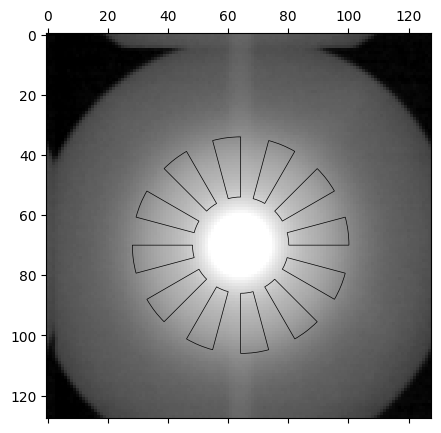

In [28]:
p_ellipse, p_dsg = py4DSTEM.process.calibration.fit_ellipse_amorphous_ring(
    data = im_SAED_amorph.data,
    center = im_SAED_amorph.calibration.get_origin_mean(),
    fitradii = q_range,
)

py4DSTEM.visualize.show_amorphous_ring_fit(
    im_SAED_amorph.data,
    fitradii = q_range,
    p_dsg = p_dsg,
)

In [29]:
# store the elliptical calibration
braggpeaks.calibration.set_p_ellipse(p_ellipse)
braggpeaks.setcal()

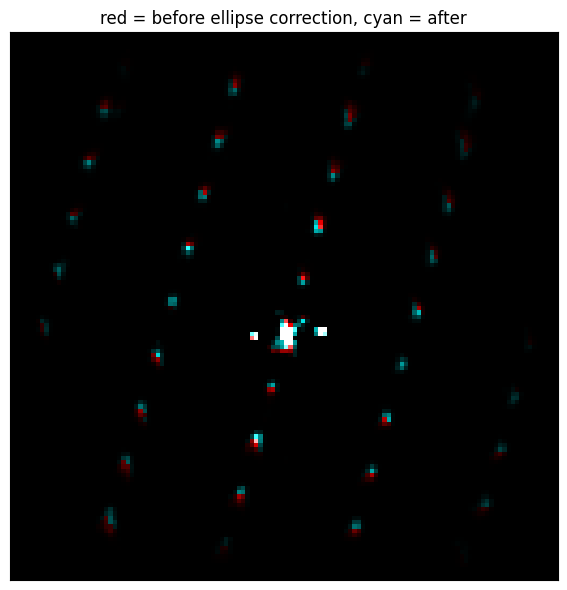

In [30]:
# compare the Bragg vector map before and after the elliptical correction
bvm_ellipse = braggpeaks.histogram(mode = 'cal')

py4DSTEM.show(
    [bvm_centered, bvm_ellipse],
    vmax = 0.999,
    combine_images = True,
    title = 'red = before ellipse correction, cyan = after',
    figsize = (6, 6),
    ticks = False,
)

## Rotation

The scan direction on the sample and the pattern orientation on the detector differ by a rotation (and possibly a transpose), set by the microscope's projector lenses. For this dataset the rotation was measured independently (using center-of-mass imaging of the direct beam — a DPC-style measurement) to be about −71° with a transpose:

In [31]:
braggpeaks.calibration.set_QR_rotation_degrees(-71)
braggpeaks.calibration.set_QR_flip(True)
braggpeaks.setcal()

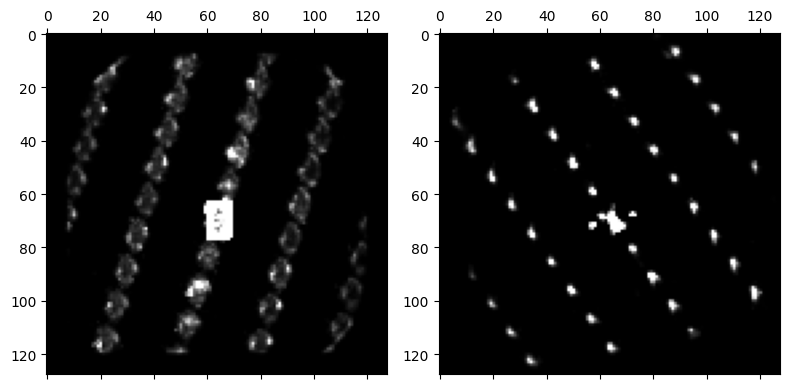

In [32]:
# the fully calibrated Bragg vector map, next to where we started
bvm = braggpeaks.histogram(mode = 'cal')

py4DSTEM.show([bvm_raw, bvm], vmax = 0.99, axsize = (4, 4))

# Strain mapping

With calibrated Bragg vectors in hand, the strain workflow is three steps:

1. **Choose lattice basis vectors** $\mathbf{g}_1, \mathbf{g}_2$ from the Bragg vector map — the two shortest independent reciprocal-lattice vectors that generate all the diffraction peaks.
2. **Fit the lattice at every probe position:** match each pattern's detected disks to integer combinations $\mathbf{q} = a\,\mathbf{g}_1 + b\,\mathbf{g}_2$ and least-squares fit the local $\mathbf{g}_1, \mathbf{g}_2$.
3. **Convert to strain:** the transformation from *reference* lattice vectors to *local* ones is the strain tensor — reported as $\varepsilon_{xx}$, $\varepsilon_{yy}$ (stretch along two axes), $\varepsilon_{xy}$ (shear), and $\theta$ (local lattice rotation).

In [33]:
strainmap = py4DSTEM.StrainMap(braggvectors = braggpeaks)

'oneOf' deprecated - use 'one_of'
'oneOf' deprecated - use 'one_of'
'leaveWhitespace' deprecated - use 'leave_whitespace'
'oneOf' deprecated - use 'one_of'
'oneOf' deprecated - use 'one_of'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse

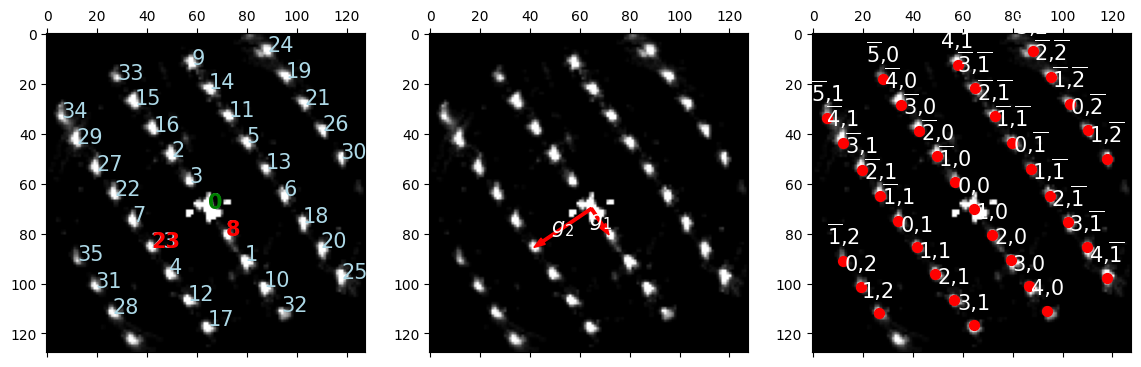

In [34]:
strainmap.choose_basis_vectors(
    minSpacing = 10,
    minAbsoluteIntensity = 1e3,
    maxNumPeaks = 100,
    edgeBoundary = 5,
    vis_params = bvm_vis_params,
    # to override the automatic choice, pass the numbered peak indices, e.g.:
    # index_g1 = 11,
    # index_g2 = 9,
)

The plot numbers the candidate peaks and marks the chosen $\mathbf{g}_1$ (red) and $\mathbf{g}_2$ (green). For LFP along [010] the natural basis pair is one short vector along the dense rows of peaks and one longer vector perpendicular to it. If the automatic choice picks a different (but valid) pair, the strain answer is the same — but you can force specific peaks with `index_g1` / `index_g2`.

Now the per-position lattice fit:

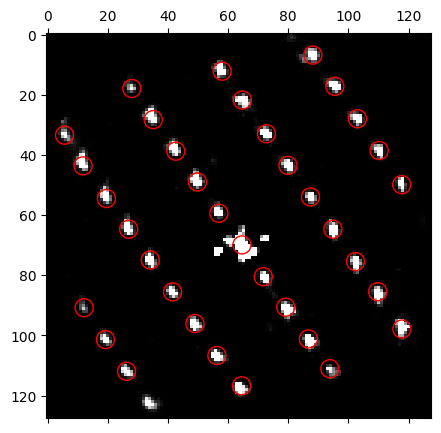

Indexing Bragg scattering: 100%|██████████| 4.05k/4.05k [00:07<00:00, 573DP/s]  
Fitting lattice vectors: 100%|██████████| 4.05k/4.05k [00:00<00:00, 4.91kDP/s]


In [35]:
strainmap.fit_basis_vectors(
    max_peak_spacing = 3,   # a detected disk must land within this many pixels
                            # of its ideal lattice site to be used in the fit
)

# The strain maps

`get_strain` computes and displays the four strain components. By default the reference lattice (defining "zero strain") is the median over the whole scan. The `coordinate_rotation` argument rotates the *display* axes — here we choose −55° so that the $x$/$y$ strain axes line up with the particle's crystal axes ($a$ and $c$).

Calculating strain: 100%|██████████| 4.05k/4.05k [00:00<00:00, 4.84kDP/s]


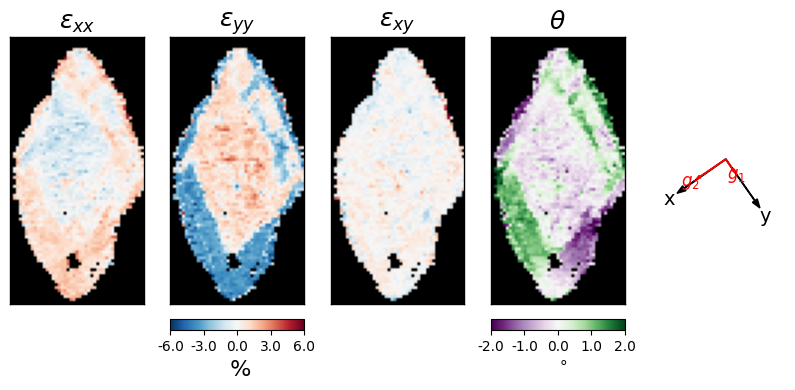

In [36]:
strainmap.get_strain(
    coordinate_rotation = -55,
    layout = 'horizontal',
    vrange = [-6.0, 6.0],
    vrange_theta = [-2.0, 2.0],
)

**Reading the maps:** $\varepsilon_{yy}$ (strain along $a$) shows a strongly contracted shell around a less-strained core — the delithiated Li-poor phase forms at the particle surface, and removing Li contracts $a$. The rotation map shows degree-scale lattice rotation domains across the platelet.

We can also draw the measurement's coordinate systems — always worth checking that the reference directions make sense relative to the images:

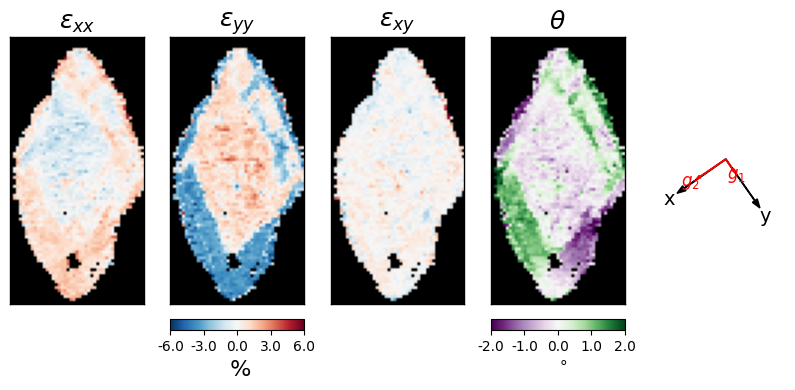

In [37]:
strainmap.show_strain(
    layout = 'horizontal',
    vrange = [-6.0, 6.0],
    vrange_theta = [-2.0, 2.0],
    show_gvects = True,
)

# Choosing a physically meaningful reference

"Strain" is always relative to a chosen zero. The scan-median reference above is a reasonable default, but here we *know* some physics: the particle core is still lithiated LFP. Using a core region as the reference makes the maps directly interpretable as strain relative to the pristine phase:

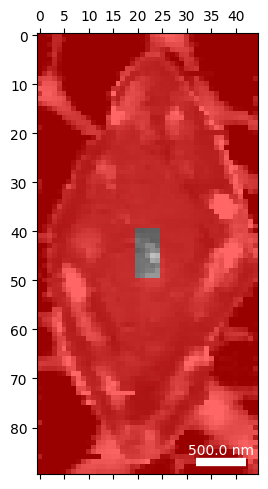

In [38]:
# choose a reference region inside the particle core
ROI = np.zeros(braggpeaks.Rshape, dtype=bool)
ROI[40:50, 20:25] = True

py4DSTEM.show(
    im_adf,
    mask = ROI,
    mask_color = 'r',
    mask_alpha = 0.4,
)

Calculating strain: 100%|██████████| 4.05k/4.05k [00:01<00:00, 2.67kDP/s]


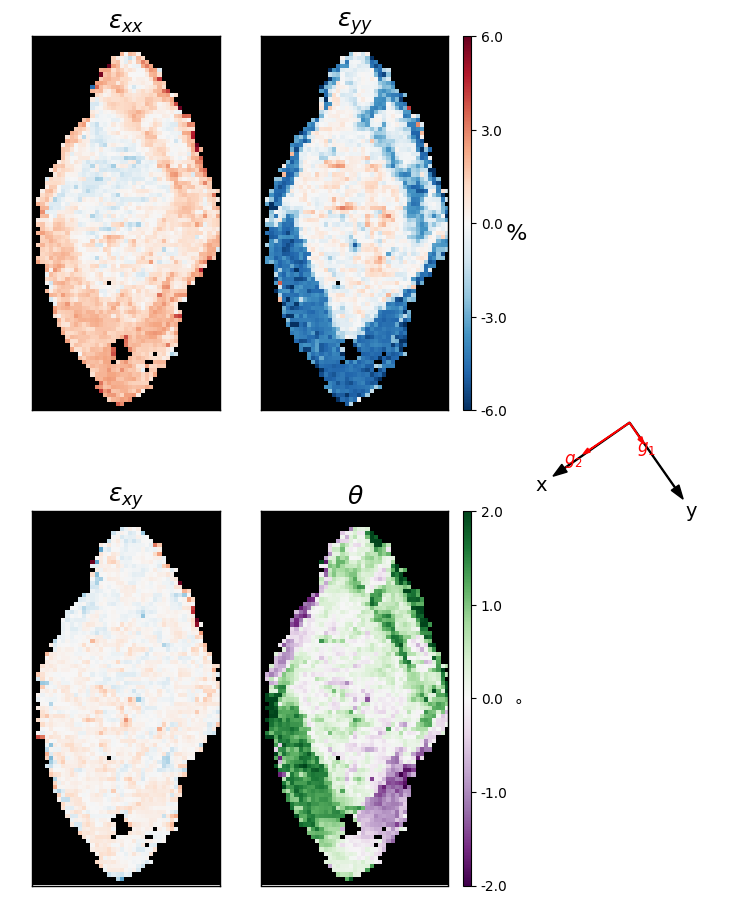

In [39]:
strainmap.get_strain(
    gvects = ROI,               # reference lattice = median over this region
    coordinate_rotation = -55,
    layout = 'square',
    vrange = [-6.0, 6.0],
    vrange_theta = [-2.0, 2.0],
)

# Recap and things to try

You measured percent-level strain in a real battery particle. The essential chain was: precise disk detection (`multicorr` subpixel) → centering (descan) → ellipticity → rotation → lattice fitting → strain relative to a chosen reference.

Some experiments to try:

- Re-run `get_strain` with `coordinate_rotation = 0` and compare — the strain *tensor* is the same, only the display axes change.
- Change the reference `ROI` to a shell region — the maps invert, because strain is relative.
- Loosen `max_peak_spacing` in `fit_basis_vectors` and watch the noise level change.
- Go back to the detection and switch `subpixel` to `poly` — how much noisier do the strain maps get?